# Lesson 3 — The Ghost Fluid Method in 1-D

Prereq: Lesson 2 (jump conditions). Reference: Paper 1 §3.

Goal: see why a naive Poisson solver **smears** a jump across the flame front, and how GFM gives a **sharp** solution using the same matrix structure. We'll build both in 1-D with `ρ = 1` for clarity, jumping `[p]` at a front at position `x = x_f`.

Model problem:

$$-p''(x) = f(x), \quad x \in [0,1], \quad p(0)=p(1)=0$$

with the requirement that `p` has a prescribed jump `[p] = p⁺ − p⁻` at `x = x_f`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, lil_matrix
from scipy.sparse.linalg import spsolve

N = 80
h = 1.0 / N
x = (np.arange(N) + 0.5) * h        # cell centers
x_f = 0.5 + 0.37 * h                 # front location, deliberately off a cell face
jump_p = 1.0                         # [p] = p(x_f+) - p(x_f-)
f = np.zeros(N)                      # no body source

# Exact analytic solution: two linear pieces, zero at both ends, jump at x_f.
# Solve -p'' = 0 on each side with p(0)=0, p(1)=0 and p(x_f+) - p(x_f-) = jump_p,
# with continuous p' (no body-force jump): p = A·x on left, p = B·(x-1) on right,
# continuity of p' ⇒ A = B, jump ⇒ A·(x_f-1) - A·x_f = jump_p ⇒ A = -jump_p.
def exact(x):
    A = -jump_p
    return np.where(x < x_f, A*x, A*(x - 1))

p_exact = exact(x)

## 1. The naive Poisson solve

Standard 3-point stencil `-p''_i ≈ (-p_{i-1} + 2 p_i - p_{i+1}) / h² = f_i`, ignoring the jump entirely.

In [14]:
# Tridiagonal Laplacian with Dirichlet BC (p = 0 at ghost cells just outside the domain)
def build_laplacian(N, h):
    main = 2.0 * np.ones(N) / h**2
    off  = -1.0 * np.ones(N-1) / h**2
    A = diags([off, main, off], [-1, 0, 1], format='lil')
    return A

A_naive = build_laplacian(N, h)
rhs_naive = f.copy()
# Dirichlet: p = 0 outside domain, absorbed into the -1/h² ghost contribution = 0.
p_naive = spsolve(A_naive.tocsr(), rhs_naive)

## 2. GFM: put the jump into the RHS

Say the front sits between cell `i = i_f` (left of front, fuel) and cell `i_f + 1` (right of front, hot). Let `θ` be the fraction of the edge `[i_f, i_f+1]` on the fuel side.

The stencil that needs fixing is the two stencils that cross the front:

- Row `i_f` uses `p_{i_f+1}` as if it were continuous with `p_{i_f}`. Subtract the jump: `p_{i_f+1}^{used} = p_{i_f+1}^{true} - [p]`.
- Row `i_f + 1` uses `p_{i_f}` the same way, but now the jump has opposite sign: `p_{i_f}^{used} = p_{i_f}^{true} + [p]`.

Both corrections move to the RHS. Matrix is unchanged.

In [8]:
# Locate front: largest i with cell-center x[i] < x_f
i_f = np.searchsorted(x, x_f) - 1
print(f'Front between cells {i_f} (x={x[i_f]:.4f}) and {i_f+1} (x={x[i_f+1]:.4f}); x_f = {x_f:.4f}')

A_gfm = build_laplacian(N, h)       # same matrix!
rhs_gfm = f.copy()
# Row i_f:  Laplacian expects (−p_{i_f+1} + 2 p_{i_f} − p_{i_f-1})/h² = f_{i_f}
# We pretend p_{i_f+1} lives on fuel side by subtracting [p]. That moves +[p]/h² to RHS.
rhs_gfm[i_f]    += -jump_p / h**2
# Row i_f+1: stencil uses p_{i_f}; pretend it lives on hot side by adding [p]. Moves −[p]/h² to RHS.
rhs_gfm[i_f+1]  +=  jump_p / h**2

p_gfm = spsolve(A_gfm.tocsr(), rhs_gfm)

Front between cells 39 (x=0.4938) and 40 (x=0.5062); x_f = 0.5046


## 3. Compare

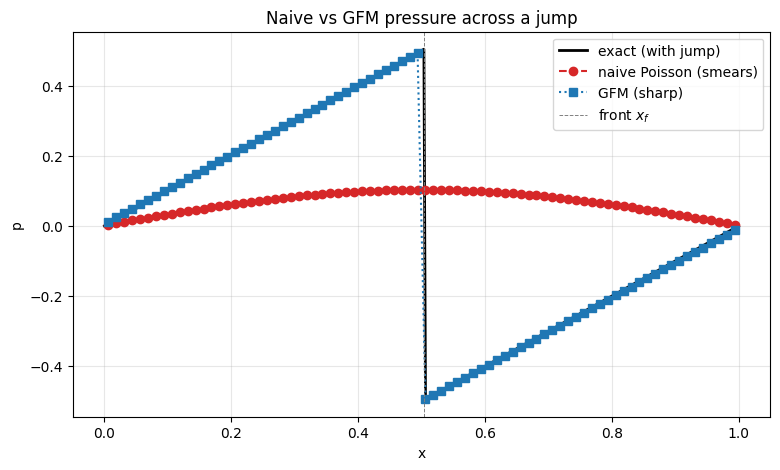

L∞ error, naive: 0.5971
L∞ error, GFM:   0.0061


In [15]:
plt.figure(figsize=(9, 5))
xx = np.linspace(0, 1, 400)
plt.plot(xx, exact(xx), 'k-', lw=2, label='exact (with jump)')
plt.plot(x, p_naive, 'o--', color='tab:red', label='naive Poisson (smears)')
plt.plot(x, p_gfm,   's:',  color='tab:blue', label='GFM (sharp)')
plt.axvline(x_f, color='gray', lw=0.7, ls='--', label='front $x_f$')
plt.legend()
plt.xlabel('x'); plt.ylabel('p')
plt.title('Naive vs GFM pressure across a jump')
plt.grid(alpha=0.3)
plt.show()

err_naive = np.abs(p_naive - p_exact).max()
err_gfm   = np.abs(p_gfm   - p_exact).max()
print(f'L∞ error, naive: {err_naive:.4f}')
print(f'L∞ error, GFM:   {err_gfm:.4f}')

Expect the naive solve to average the jump away — zero everywhere because the RHS is zero and no boundary forces a step. The GFM solve matches the exact two-piece linear solution up to first-order error at the front.

**Takeaway so far:**
- **Matrix unchanged** — same tridiagonal Laplacian, same CG solver would work.
- **RHS gets `±[p]/h²` on two cells** straddling the front.
- Section 5 below generalizes this to position-dependent density (`ρ_f ≠ ρ_h`) — which is the actual fire setup. The velocity-jump `[V·n]` enters the RHS the same way, through the divergence term.

## 4. Refinement study (optional)

Convergence rate of GFM should be `O(h)` at the jump and `O(h²)` away from it. Run at multiple N and plot error vs h.

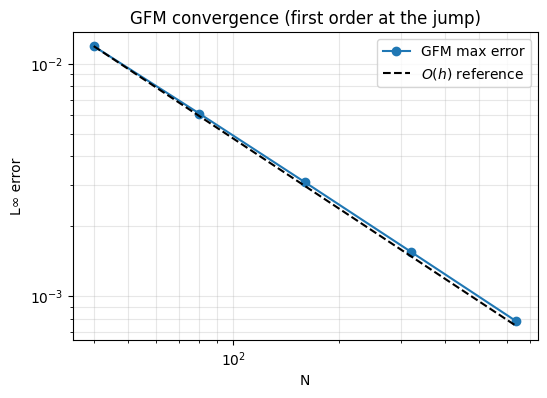

In [16]:
Ns = [40, 80, 160, 320, 640]
errs = []
for N in Ns:
    h = 1.0 / N
    x = (np.arange(N) + 0.5) * h
    x_f_local = 0.5 + 0.37 * h
    i_f = np.searchsorted(x, x_f_local) - 1
    A = build_laplacian(N, h)
    rhs = np.zeros(N)
    rhs[i_f]   += -jump_p / h**2
    rhs[i_f+1] +=  jump_p / h**2
    p = spsolve(A.tocsr(), rhs)
    p_ex = np.where(x < x_f_local, -jump_p*x, -jump_p*(x-1))
    errs.append(np.abs(p - p_ex).max())

plt.figure(figsize=(6, 4))
plt.loglog(Ns, errs, 'o-', label='GFM max error')
plt.loglog(Ns, [errs[0]*Ns[0]/N for N in Ns], 'k--', label=r'$O(h)$ reference')
plt.xlabel('N'); plt.ylabel('L∞ error'); plt.legend(); plt.grid(which='both', alpha=0.3)
plt.title('GFM convergence (first order at the jump)')
plt.show()

## 5. Variable density — the full fire problem

Up to here we took `ρ = 1` everywhere so we could focus on the jump trick. The real fire simulation has `ρ_f` on the fuel side and `ρ_h` on the hot side, with `ρ_f / ρ_h ≈ 8`. The pressure Poisson equation becomes

$$-\frac{d}{dx}\!\left(\frac{1}{\rho}\frac{dp}{dx}\right) \,=\, f$$

instead of `-p'' = f`. On each side, `ρ` is constant so the equation still reduces to a linear-piecewise `p`. But the diffusion coefficient `1/ρ` jumps at the front, and we need an *effective* face coefficient that handles both the density jump **and** the pressure jump in one step.

### Deriving the effective face density

Consider the face between cell `k` (fuel, density `ρ_f`) and cell `k+1` (hot, density `ρ_h`), with the front at `x_f` between them. Let

$$\theta = \frac{x_f - x_k}{h}$$

be the fraction of the cell-center-to-cell-center segment on the **left** cell's side.

Inside each side, `p` is linear (constant `ρ`, no body force). Let `p_f^*` and `p_h^*` be the limiting pressures at `x_f` from the fuel and hot sides. By the jump condition, `p_h^* − p_f^* = [p]`.

The finite-volume flux `J = (1/ρ)·dp/dx` must be continuous across the front (momentum balance with no viscous jump). On each sub-segment:

$$J = \frac{1}{\rho_f}\cdot\frac{p_f^* - p_k}{\theta\,h} = \frac{1}{\rho_h}\cdot\frac{p_{k+1} - p_h^*}{(1-\theta)\,h}$$

Solve for `p_f^*` from the first equation, for `p_h^*` from the second, subtract, apply the jump:

$$J = \frac{p_{k+1} - p_k - [p]}{h\bigl(\theta\,\rho_f + (1-\theta)\,\rho_h\bigr)}$$

So the **effective face density** is a length-weighted arithmetic mean of the two side densities:

$$\boxed{\;\hat\rho \;=\; \theta\,\rho_k + (1-\theta)\,\rho_{k+1}\;}$$

Equivalently `1/ρ̂` is the length-weighted harmonic mean of the conductances `1/ρ_f` and `1/ρ_h` — exactly what series-resistance intuition demands, since flux runs in series through the two sub-segments.

Faces that don't cross the front just get `ρ̂ = ρ_f` or `ρ̂ = ρ_h` outright.

### Plugging it into the matrix

With `ρ̂` in hand, the tridiagonal system becomes:

- **Off-diagonal** for the face between cells `k` and `k+1`:  `−1/(ρ̂ h²)`  (using the local `ρ̂`, which for non-crossing faces is just `1/ρ_f` or `1/ρ_h`).
- **Diagonal** for cell `i`: sum of the two adjacent-face coefficients (positive).
- **Dirichlet walls**: model a ghost cell at `p = 0` a distance `h/2` outside the domain. Algebraically, that doubles the wall-face coefficient `→ 2/(ρ_wall h²)` on the diagonal.

**RHS jump term** — scaled by the same face coefficient `1/(ρ̂ h²)`, not by `1/h²` as in the constant-ρ version:

```
rhs[k]   += - (1/(ρ̂·h²)) · [p]     if cell k is fuel, cell k+1 is hot
rhs[k+1] += + (1/(ρ̂·h²)) · [p]
```

Signs flip if the front orientation reverses (hot on left, fuel on right). The matrix stays symmetric positive-definite.

**Exact solution (for testing).** With `f = 0` and Dirichlet walls at 0 and 1: `p(x) = A·x` for `x < x_f`, `p(x) = B·(x−1)` for `x > x_f`, where

$$A = \frac{-[p]\,\rho_f}{\rho_h(1-x_f) + \rho_f\,x_f}, \qquad B = \frac{-[p]\,\rho_h}{\rho_h(1-x_f) + \rho_f\,x_f}$$

The slope ratio `A/B = ρ_f/ρ_h`.

In [ ]:
def solve_gfm_variable_rho(N, h, x_f, rho_f, rho_h, jump_p, f):
    """Solve -d/dx((1/rho) dp/dx) = f on [0,1] with Dirichlet p=0 at both ends.
    Front at x_f splits fuel (left, density rho_f) from hot (right, density rho_h).
    """
    x = (np.arange(N) + 0.5) * h
    in_fuel = x < x_f
    rho_cell = np.where(in_fuel, rho_f, rho_h)

    # Per-face effective 1/rho between cell k and cell k+1, for k = 0 .. N-2
    inv_rho_face = np.empty(N - 1)
    for k in range(N - 1):
        if in_fuel[k] == in_fuel[k+1]:
            inv_rho_face[k] = 1.0 / rho_cell[k]
        else:
            theta = (x_f - x[k]) / h                           # fraction on cell-k side
            rho_hat = theta * rho_cell[k] + (1 - theta) * rho_cell[k+1]
            inv_rho_face[k] = 1.0 / rho_hat

    coef = inv_rho_face / h**2                                 # interior face conductances
    # Dirichlet walls: ghost cell at p=0 a distance h/2 outside; doubles the wall-face coef.
    wall_left  = (1.0 / rho_cell[0])  * 2 / h**2
    wall_right = (1.0 / rho_cell[-1]) * 2 / h**2

    main = np.zeros(N); sub = np.zeros(N-1); sup = np.zeros(N-1)
    for i in range(N):
        if i > 0:
            main[i] += coef[i-1]; sub[i-1] = -coef[i-1]
        else:
            main[i] += wall_left
        if i < N - 1:
            main[i] += coef[i]; sup[i] = -coef[i]
        else:
            main[i] += wall_right

    rhs = f.copy()
    for k in range(N - 1):
        if in_fuel[k] != in_fuel[k+1]:
            c = coef[k]                                         # = 1/(rho_hat * h^2)
            if in_fuel[k]:     # fuel | hot  → [p] = p_hot - p_fuel
                rhs[k]   += -c * jump_p
                rhs[k+1] += +c * jump_p
            else:              # hot | fuel  → sign flips
                rhs[k]   += +c * jump_p
                rhs[k+1] += -c * jump_p

    A = diags([sub, main, sup], [-1, 0, 1], format='csr')
    return spsolve(A, rhs)


# --- Test ------------------------------------------------------------------
N = 80; h = 1/N
rho_f = 1.0; rho_h = 0.125                          # ρ_f / ρ_h = 8, typical for fire
x_f   = 0.5 + 0.37 * h
jump_p = 1.0
f = np.zeros(N)
x = (np.arange(N) + 0.5) * h

# Exact two-piece linear solution
D = rho_h * (1 - x_f) + rho_f * x_f
A_ex = -jump_p * rho_f / D
B_ex = -jump_p * rho_h / D
p_exact_cells = np.where(x < x_f, A_ex * x, B_ex * (x - 1))

p_num = solve_gfm_variable_rho(N, h, x_f, rho_f, rho_h, jump_p, f)

plt.figure(figsize=(9, 5))
xx = np.linspace(0, 1, 400)
p_exact_fine = np.where(xx < x_f, A_ex * xx, B_ex * (xx - 1))
plt.plot(xx, p_exact_fine, 'k-', lw=2, label='exact')
plt.plot(x, p_num, 's:', color='tab:blue', label='GFM, variable ρ')
plt.axvline(x_f, color='gray', lw=0.7, ls='--', label='front $x_f$')
plt.legend(); plt.xlabel('x'); plt.ylabel('p'); plt.grid(alpha=0.3)
plt.title(f'Variable-ρ GFM: ρ_f={rho_f}, ρ_h={rho_h}, [p]={jump_p}')
plt.show()

print(f'Slope ratio (expected ρ_f/ρ_h = {rho_f/rho_h:.1f}):  A/B = {A_ex/B_ex:.2f}')
print(f'L∞ error vs exact: {np.abs(p_num - p_exact_cells).max():.4f}')

### What to notice

1. The two linear pieces have **different slopes** — slope ratio is `ρ_f : ρ_h = 8 : 1`. Flux `(1/ρ)·dp/dx` is still continuous; the pressure gradient absorbs the asymmetry.
2. The jump at `x_f` is preserved exactly at the grid resolution, just like the constant-ρ case.
3. Try Exercise 3: patch the code to use `ρ_f` at the crossing face instead of `ρ̂`. The plot distinguishes the two trivially — one side gets the wrong slope.

### Plugging this into a 2-D / 3-D MAC-grid fire solver

Same recipe, face by face:

- **Classify each MAC face** as fuel, hot, or front-crossing using the level-set values `φ` at the two adjacent cell centers: same sign → interior face; opposite sign → crossing face.
- **Fuel faces** get coefficient `1/ρ_f`; **hot faces** get `1/ρ_h`.
- **Front-crossing faces** get `1/ρ̂` with `θ = φ_near / (φ_near − φ_far)` — the standard linear interpolation to locate the front on the edge — and `ρ̂ = θ·ρ_near + (1−θ)·ρ_far`.
- **Jump `[p]`** enters the RHS with factor `1/(ρ̂·h²)` on the two cells straddling each crossing face.
- **Jump `[V·n]`** from Lesson 2 enters through the divergence RHS term the same way.

The LHS matrix stays symmetric positive-definite, so CG or ICPCG still works. That is the full GFM pressure projection for fire.

## Exercises

1. Change `jump_p` to a negative number and re-solve (top of cell 1). The pressure step flips sign as expected.
2. Add a nonzero body source `f = np.sin(np.pi * x)` and confirm GFM still gets it right. (The exact solution changes — you'll need to re-derive it or just sanity-check visually against a refined grid.)
3. In Section 5's variable-ρ solver, deliberately patch the code to use `ρ_f` at the front-crossing face instead of `ρ̂`. Plot the result against the exact solution to see which slope goes wrong.
4. Extend Section 5 to include a pressure jump `[p]` that depends on local flame-speed curvature (`S(κ) = S₀(1 − M·κ)` from Paper 3). In 1-D there's no curvature, so use a synthetic `[p](x_f)` that varies with `x_f` to confirm the machinery still works.